In [3]:
# Importing Required Libraries

import pandas as pd
import numpy as np

# Reading the Dataset

df = pd.read_csv("student_mental_health_burnout.csv")

# Display Dataset Shape

print("Dataset Shape:", df.shape)

# Display First 5 Records

df.head()

Dataset Shape: (150000, 20)


,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  object 
 3   course                   150000 non-null  object 
 4   year                     150000 non-null  object 
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  object 
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  phys

In [5]:
df.isnull().sum()

student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_level              0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df = df.drop('student_id', axis=1)

In [8]:
print(df.columns.tolist())

['age', 'gender', 'course', 'year', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours', 'stress_level', 'anxiety_score', 'depression_score', 'academic_pressure_score', 'financial_stress_score', 'social_support_score', 'physical_activity_hours', 'sleep_quality', 'attendance_percentage', 'cgpa', 'internet_quality', 'burnout_level']


In [9]:
print(df.shape)

(150000, 19)


In [10]:
df.describe()

,age,daily_study_hours,daily_sleep_hours,screen_time_hours,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,attendance_percentage,cgpa
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,21.000380,5.507869,6.499361,6.502819,5.493907,5.497360,5.507427,5.496027,5.516060,0.998115,75.009528,6.997389
std,2.581216,2.595592,1.443859,3.178948,2.872607,2.869022,2.875524,2.864698,2.870493,0.578866,14.409510,1.732180
min,17.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,50.000000,4.000000
25%,19.000000,3.300000,5.200000,3.700000,3.000000,3.000000,3.000000,3.000000,3.000000,0.500000,62.500000,5.500000
50%,21.000000,5.500000,6.500000,6.500000,5.000000,5.000000,6.000000,6.000000,6.000000,1.000000,75.000000,6.990000
75%,23.000000,7.700000,7.700000,9.300000,8.000000,8.000000,8.000000,8.000000,8.000000,1.500000,87.500000,8.500000
max,25.000000,10.000000,9.000000,12.000000,10.000000,10.000000,10.000000,10.000000,10.000000,2.000000,100.000000,10.000000


In [11]:
for col in df.select_dtypes(include='object'):
    print(col)
    print(df[col].unique())
    print()

gender
['Male' 'Female' 'Other']

course
['BTech' 'BCA' 'BSc' 'MBA' 'MCA' 'BBA']

year
['1st' '3rd' '4th' '2nd']

stress_level
['High' 'Low' 'Medium']

sleep_quality
['Average' 'Poor' 'Good']

internet_quality
['Good' 'Poor' 'Average']

burnout_level
['High' 'Low' 'Medium']



In [12]:
df['Rest_to_Work_Ratio'] = (
    df['daily_sleep_hours']
    + df['physical_activity_hours']
) / (
    df['daily_study_hours']
    + df['screen_time_hours']
)

df['Rest_to_Work_Ratio'].describe()

count    150000.000000
mean          0.731422
std           0.401629
min           0.186047
25%           0.477419
50%           0.624161
75%           0.851852
max           4.909091
Name: Rest_to_Work_Ratio, dtype: float64

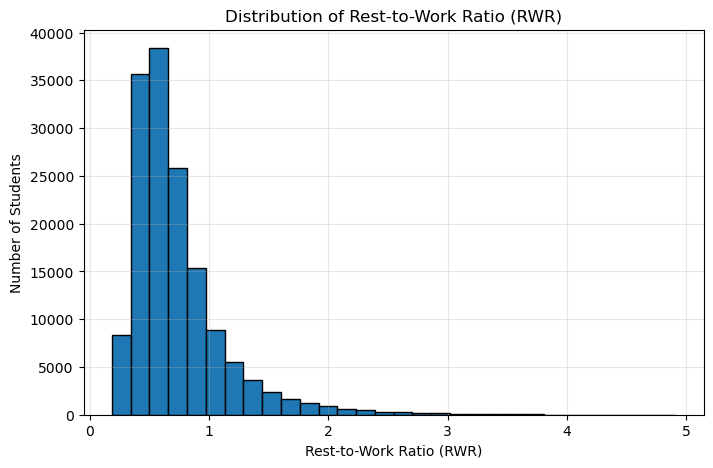

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df['Rest_to_Work_Ratio'], bins=30, edgecolor='black')

plt.title("Distribution of Rest-to-Work Ratio (RWR)")
plt.xlabel("Rest-to-Work Ratio (RWR)")
plt.ylabel("Number of Students")

plt.grid(True, alpha=0.3)

plt.show()

In [90]:
print(df['burnout_level'].value_counts())

burnout_level
Low       50265
Medium    49969
High      49766
Name: count, dtype: int64


In [91]:
df.describe()

,age,daily_study_hours,daily_sleep_hours,screen_time_hours,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,attendance_percentage,cgpa,Rest_to_Work_Ratio
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,21.000380,5.507869,6.499361,6.502819,5.493907,5.497360,5.507427,5.496027,5.516060,0.998115,75.009528,6.997389,0.731422
std,2.581216,2.595592,1.443859,3.178948,2.872607,2.869022,2.875524,2.864698,2.870493,0.578866,14.409510,1.732180,0.401629
min,17.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,50.000000,4.000000,0.186047
25%,19.000000,3.300000,5.200000,3.700000,3.000000,3.000000,3.000000,3.000000,3.000000,0.500000,62.500000,5.500000,0.477419
50%,21.000000,5.500000,6.500000,6.500000,5.000000,5.000000,6.000000,6.000000,6.000000,1.000000,75.000000,6.990000,0.624161
75%,23.000000,7.700000,7.700000,9.300000,8.000000,8.000000,8.000000,8.000000,8.000000,1.500000,87.500000,8.500000,0.851852
max,25.000000,10.000000,9.000000,12.000000,10.000000,10.000000,10.000000,10.000000,10.000000,2.000000,100.000000,10.000000,4.909091


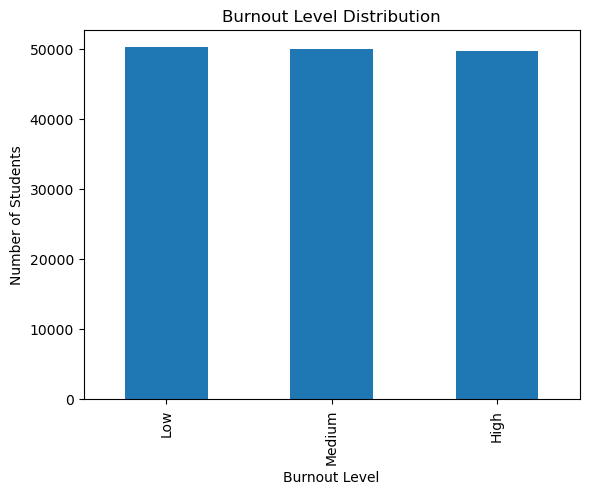

In [92]:
import matplotlib.pyplot as plt

df['burnout_level'].value_counts().plot(kind='bar')

plt.title('Burnout Level Distribution')
plt.xlabel('Burnout Level')
plt.ylabel('Number of Students')

plt.show()

In [18]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

corr_matrix

,age,daily_study_hours,daily_sleep_hours,screen_time_hours,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,attendance_percentage,cgpa,Rest_to_Work_Ratio
age,1.000000,-0.000623,0.003084,-0.001495,0.001606,-0.001968,0.000551,-0.001328,-0.000104,-0.003325,-0.002459,-0.003290,0.001843
daily_study_hours,-0.000623,1.000000,-0.002353,0.001779,0.002771,-0.001497,-0.003118,0.001919,-0.003394,0.001722,-0.000155,-0.005450,-0.506816
daily_sleep_hours,0.003084,-0.002353,1.000000,0.001453,0.003168,-0.001608,-0.002160,0.004840,-0.002535,-0.000076,-0.000672,-0.005004,0.351732
screen_time_hours,-0.001495,0.001779,0.001453,1.000000,-0.000441,0.002552,-0.000651,0.006404,-0.000779,-0.000003,0.001161,0.002744,-0.594534
anxiety_score,0.001606,0.002771,0.003168,-0.000441,1.000000,-0.001782,0.000503,-0.001421,0.002810,-0.001478,-0.000118,0.001136,-0.000009
depression_score,-0.001968,-0.001497,-0.001608,0.002552,-0.001782,1.000000,0.000599,0.002993,0.000227,0.001040,-0.001282,-0.002124,-0.001568
academic_pressure_score,0.000551,-0.003118,-0.002160,-0.000651,0.000503,0.000599,1.000000,0.002935,-0.002619,-0.000909,-0.002217,0.001213,0.000178
financial_stress_score,-0.001328,0.001919,0.004840,0.006404,-0.001421,0.002993,0.002935,1.000000,-0.002216,-0.004280,0.003911,0.000553,-0.005864
social_support_score,-0.000104,-0.003394,-0.002535,-0.000779,0.002810,0.000227,-0.002619,-0.002216,1.000000,-0.007241,0.000196,-0.000425,-0.000882
physical_activity_hours,-0.003325,0.001722,-0.000076,-0.000003,-0.001478,0.001040,-0.000909,-0.004280,-0.007241,1.000000,0.003524,0.002510,0.140339


In [19]:
X = df.drop('burnout_level', axis=1)

y = df['burnout_level']

print(X.shape)
print(y.shape)

(150000, 19)
(150000,)


In [20]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(150000, 29)


In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [22]:
df

,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level,Rest_to_Work_Ratio
0,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High,0.826923
1,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low,1.500000
2,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High,1.076923
3,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High,0.860465
4,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low,1.135135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,24,Female,BSc,3rd,1.6,8.2,11.3,Medium,9,9,5,3,10,2.0,Good,54.2,7.82,Good,Low,0.790698
149996,25,Male,BCA,3rd,9.9,4.8,1.6,High,10,3,10,10,2,0.1,Poor,53.6,7.19,Average,High,0.426087
149997,22,Male,BTech,1st,1.4,4.4,4.6,High,10,8,6,4,7,1.6,Good,90.7,9.78,Average,High,1.000000
149998,19,Male,BSc,3rd,1.5,4.3,1.1,Medium,8,6,5,7,4,1.1,Average,83.9,9.88,Average,Medium,2.076923


In [23]:
print(df.shape)

(150000, 20)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(120000, 29)
(30000, 29)
(120000,)
(30000,)


In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Model Training Completed Successfully!")

Model Training Completed Successfully!


In [26]:
y_pred = rf.predict(X_test)

print(y_pred[:10])

[2 2 1 1 1 1 2 0 0 0]


In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.33      0.34      0.34     10021
           1       0.33      0.35      0.34     10024
           2       0.34      0.32      0.33      9955

    accuracy                           0.34     30000
   macro avg       0.34      0.33      0.33     30000
weighted avg       0.34      0.34      0.33     30000



In [28]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.335


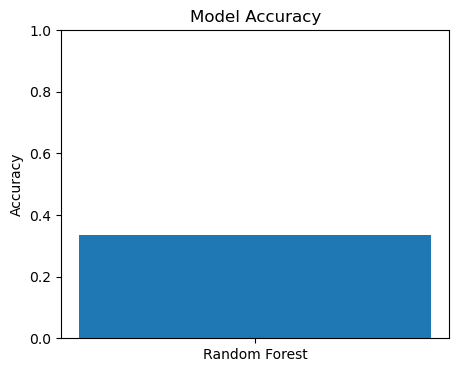

In [29]:
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred)

plt.figure(figsize=(5,4))

plt.bar(['Random Forest'], [accuracy])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.show()

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[3430 3524 3067]
 [3395 3469 3160]
 [3436 3368 3151]]


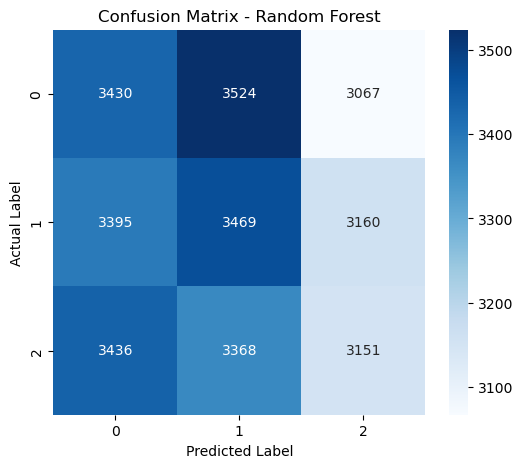

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Random Forest")

plt.show()

In [32]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                    Feature  Importance
11                     cgpa    0.083821
10    attendance_percentage    0.083217
12       Rest_to_Work_Ratio    0.082818
1         daily_study_hours    0.075272
3         screen_time_hours    0.075123
2         daily_sleep_hours    0.069763
9   physical_activity_hours    0.060644
7    financial_stress_score    0.049055
4             anxiety_score    0.048659
8      social_support_score    0.048188


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.33      0.34      0.34     10021
           1       0.33      0.35      0.34     10024
           2       0.34      0.32      0.33      9955

    accuracy                           0.34     30000
   macro avg       0.34      0.33      0.33     30000
weighted avg       0.34      0.34      0.33     30000



In [34]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy)

Accuracy = 0.335


In [35]:
pd.crosstab(df['stress_level'], df['burnout_level'])

burnout_level,High,Low,Medium
stress_level,,,
High,16768,16868,16659
Low,16357,16711,16547
Medium,16641,16686,16763


In [36]:
pd.crosstab(df['sleep_quality'], df['burnout_level'])

burnout_level,High,Low,Medium
sleep_quality,,,
Average,16497,16764,16715
Good,16571,16717,16855
Poor,16698,16784,16399


In [37]:
df.groupby('burnout_level')[[
    'anxiety_score',
    'depression_score',
    'academic_pressure_score',
    'financial_stress_score'
]].mean()

,anxiety_score,depression_score,academic_pressure_score,financial_stress_score
burnout_level,,,,
High,5.486276,5.497287,5.526002,5.502150
Low,5.500428,5.490401,5.500249,5.494638
Medium,5.494947,5.504433,5.496148,5.491325


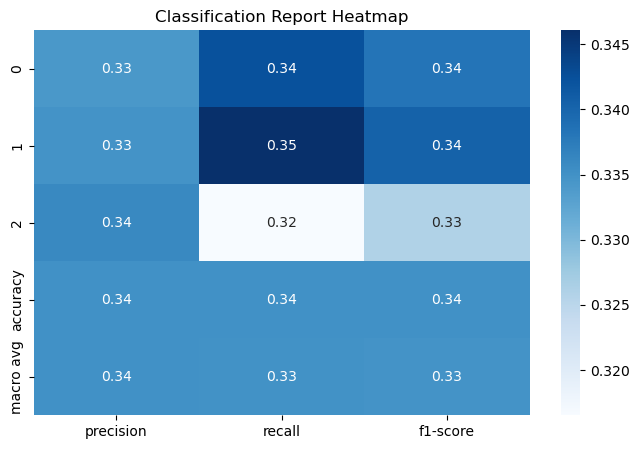

In [38]:
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,5))

sns.heatmap(
    report_df.iloc[:-1, :-1],
    annot=True,
    cmap='Blues'
)

plt.title("Classification Report Heatmap")

plt.show()

In [39]:
import joblib

joblib.dump(rf, 'random_forest_model.pkl')

['random_forest_model.pkl']

In [40]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

from sklearn.metrics import accuracy_score

acc_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy =", acc_dt)

Decision Tree Accuracy = 0.3367


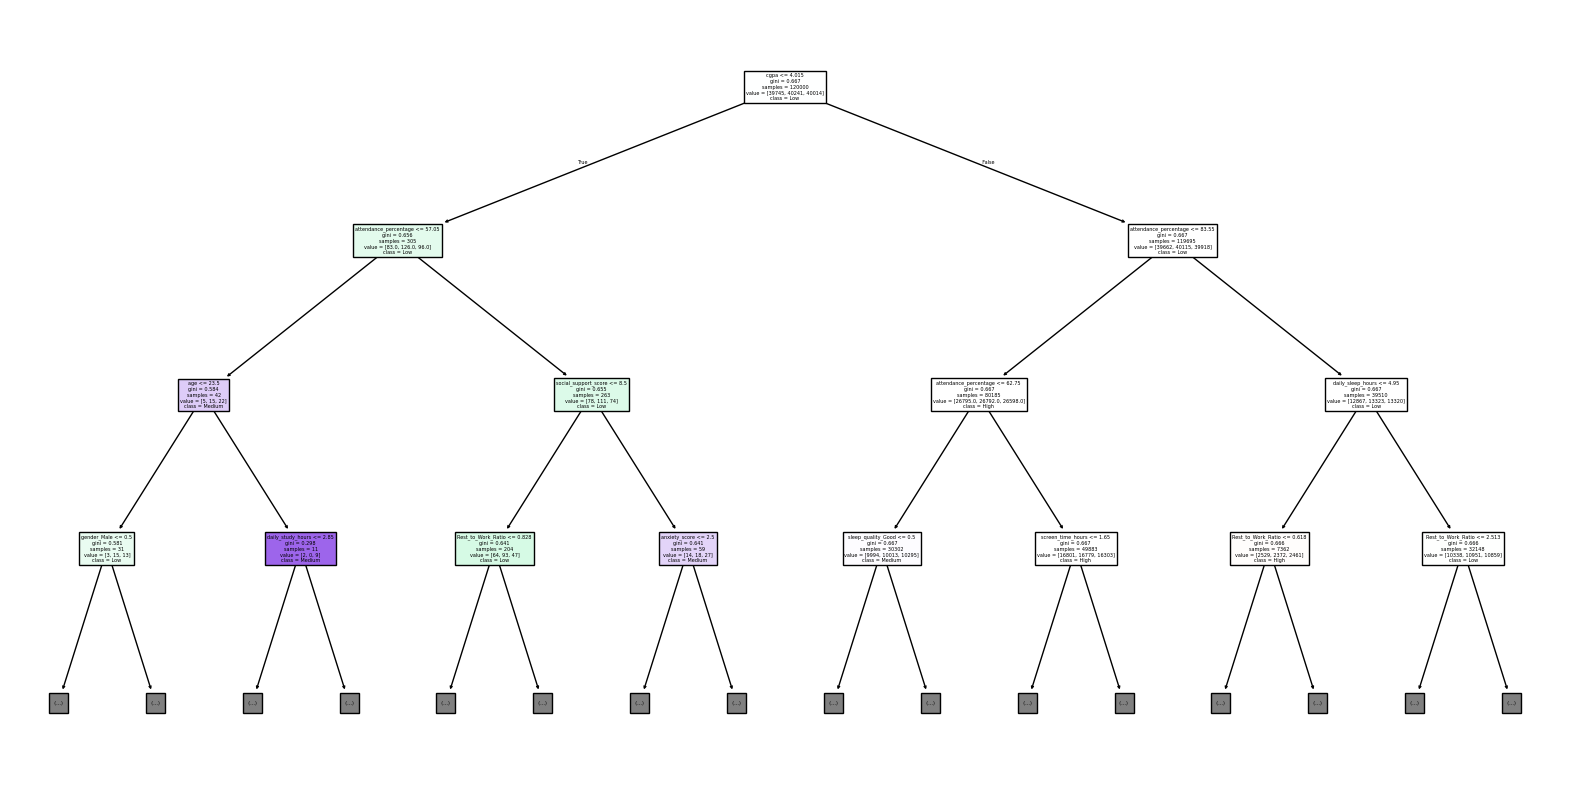

In [41]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    max_depth=3,
    filled=True,
    feature_names=X.columns,
    class_names=['High','Low','Medium']
)

plt.show()

In [42]:
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[3323 3341 3357]
 [3181 3376 3467]
 [3222 3331 3402]]


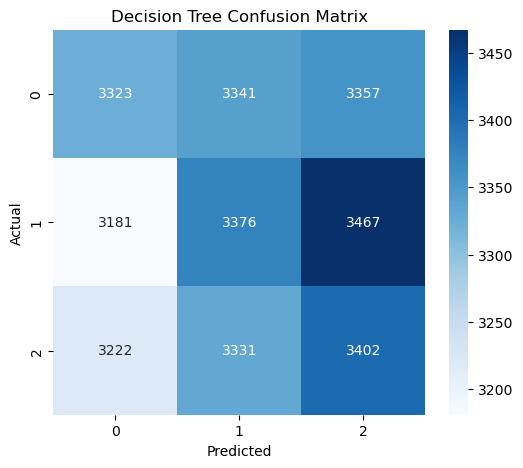

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.34      0.33      0.34     10021
           1       0.34      0.34      0.34     10024
           2       0.33      0.34      0.34      9955

    accuracy                           0.34     30000
   macro avg       0.34      0.34      0.34     30000
weighted avg       0.34      0.34      0.34     30000



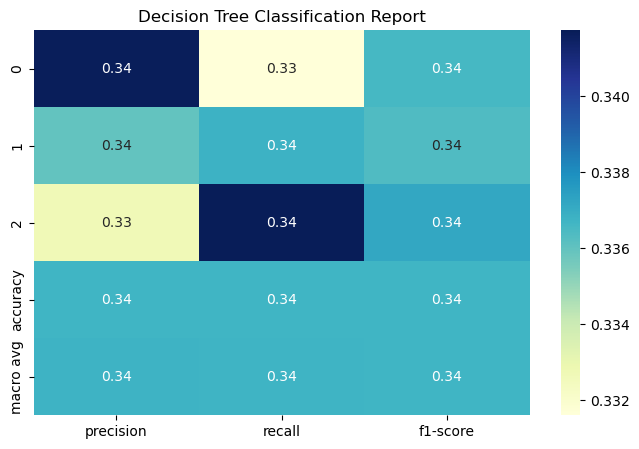

In [45]:
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

report = classification_report(
    y_test,
    y_pred_dt,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,5))

sns.heatmap(
    report_df.iloc[:-1, :-1],
    annot=True,
    cmap='YlGnBu'
)

plt.title("Decision Tree Classification Report")
plt.show()

In [46]:
importance_dt = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
})

importance_dt = importance_dt.sort_values(
    by='Importance',
    ascending=False
)

print(importance_dt.head(10))

                    Feature  Importance
11                     cgpa    0.096831
12       Rest_to_Work_Ratio    0.089273
10    attendance_percentage    0.087024
3         screen_time_hours    0.076844
1         daily_study_hours    0.074366
2         daily_sleep_hours    0.067761
9   physical_activity_hours    0.062725
7    financial_stress_score    0.051066
5          depression_score    0.050333
8      social_support_score    0.049160


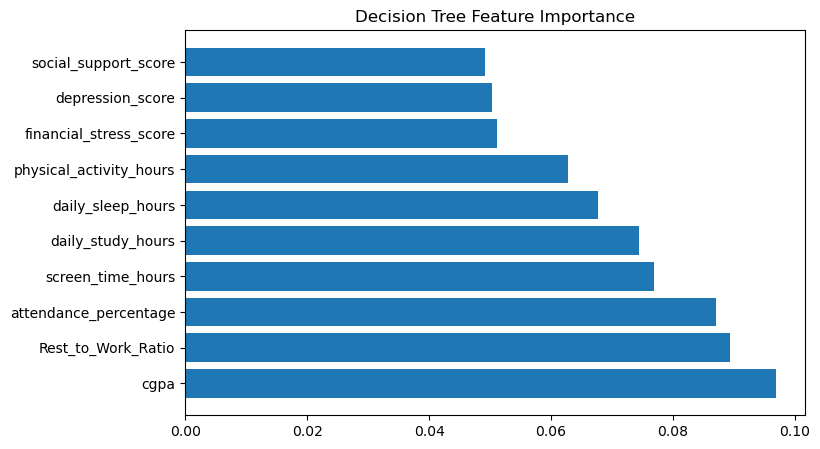

In [47]:
top10 = importance_dt.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.title("Decision Tree Feature Importance")

plt.show()

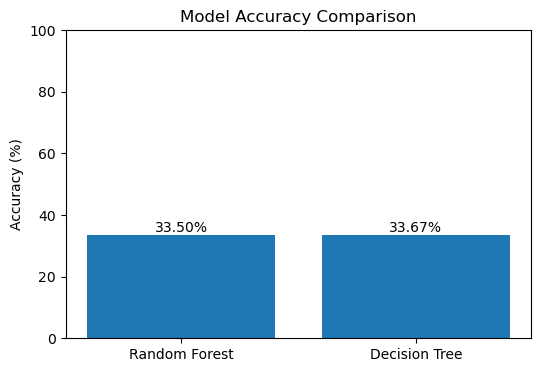

In [48]:
import matplotlib.pyplot as plt

models = ['Random Forest', 'Decision Tree']
accuracy = [33.50, 33.67]

plt.figure(figsize=(6,4))

bars = plt.bar(models, accuracy)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.2f}%',
        ha='center'
    )

plt.show()

In [52]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

from sklearn.metrics import accuracy_score

acc_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy =", acc_lr)

Logistic Regression Accuracy = 0.3337333333333333


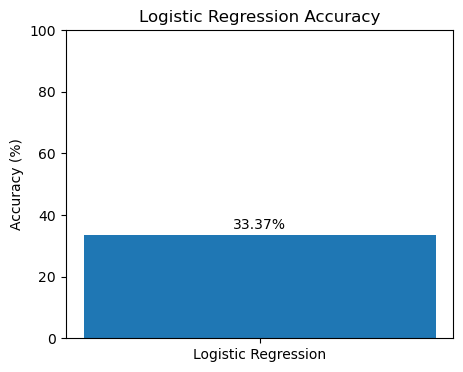

In [53]:
import matplotlib.pyplot as plt

accuracy = 33.37

plt.figure(figsize=(5,4))

plt.bar(['Logistic Regression'], [accuracy])

plt.title('Logistic Regression Accuracy')
plt.ylabel('Accuracy (%)')
plt.ylim(0,100)

plt.text(
    0,
    accuracy+2,
    f'{accuracy:.2f}%',
    ha='center'
)

plt.show()

In [54]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

print(cm_lr)

[[2256 4364 3401]
 [2251 4396 3377]
 [2210 4385 3360]]


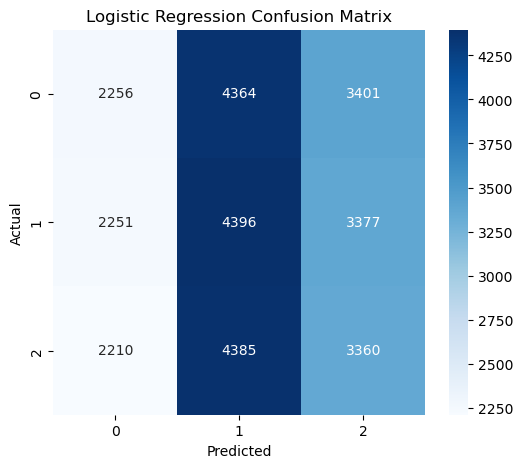

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Logistic Regression Confusion Matrix'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [56]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.34      0.23      0.27     10021
           1       0.33      0.44      0.38     10024
           2       0.33      0.34      0.33      9955

    accuracy                           0.33     30000
   macro avg       0.33      0.33      0.33     30000
weighted avg       0.33      0.33      0.33     30000



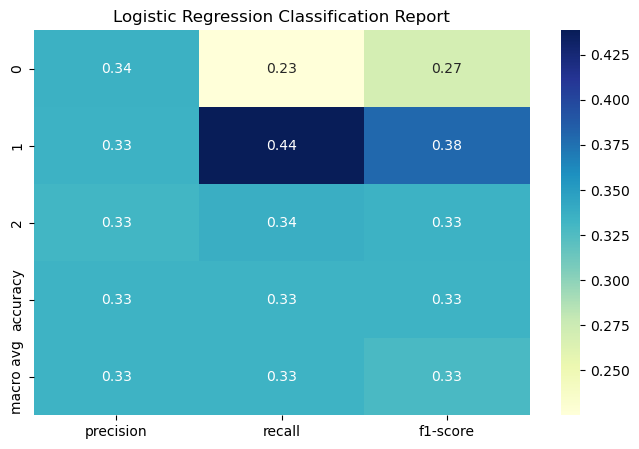

In [57]:
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

report = classification_report(
    y_test,
    y_pred_lr,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,5))

sns.heatmap(
    report_df.iloc[:-1,:-1],
    annot=True,
    cmap='YlGnBu'
)

plt.title(
    'Logistic Regression Classification Report'
)

plt.show()

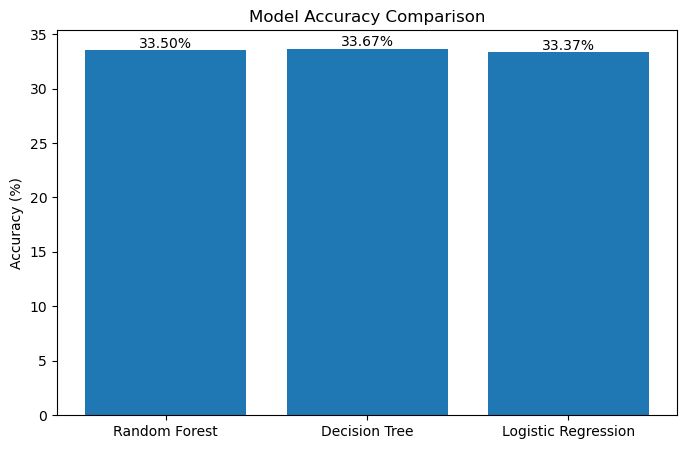

In [58]:
import matplotlib.pyplot as plt

models = [
    'Random Forest',
    'Decision Tree',
    'Logistic Regression'
]

accuracy = [
    33.50,
    33.67,
    33.37
]

plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracy)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+0.2,
        f'{h:.2f}%',
        ha='center'
    )

plt.show()

In [59]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

from sklearn.metrics import accuracy_score

acc_knn = accuracy_score(
    y_test,
    y_pred_knn
)

print(
    "KNN Accuracy =",
    acc_knn
)

KNN Accuracy = 0.33763333333333334


In [60]:
from sklearn.metrics import confusion_matrix

cm_knn = confusion_matrix(y_test, y_pred_knn)

print(cm_knn)

[[4558 3406 2057]
 [4509 3441 2074]
 [4506 3319 2130]]


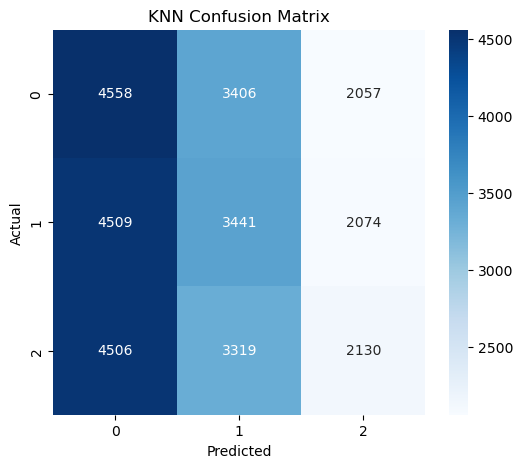

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [62]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_knn
    )
)

              precision    recall  f1-score   support

           0       0.34      0.45      0.39     10021
           1       0.34      0.34      0.34     10024
           2       0.34      0.21      0.26      9955

    accuracy                           0.34     30000
   macro avg       0.34      0.34      0.33     30000
weighted avg       0.34      0.34      0.33     30000



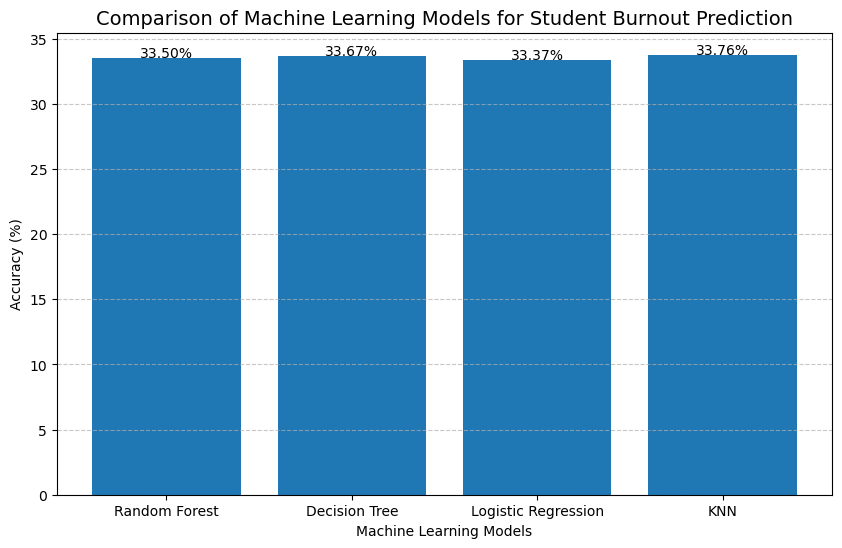

In [63]:
import matplotlib.pyplot as plt

models = [
    'Random Forest',
    'Decision Tree',
    'Logistic Regression',
    'KNN'
]

accuracy = [
    33.50,
    33.67,
    33.37,
    33.76
]

plt.figure(figsize=(10,6))

bars = plt.bar(models, accuracy)

plt.title(
    'Comparison of Machine Learning Models for Student Burnout Prediction',
    fontsize=14
)

plt.xlabel('Machine Learning Models')
plt.ylabel('Accuracy (%)')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f'{bar.get_height():.2f}%',
        ha='center'
    )

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [64]:
from sklearn.model_selection import train_test_split

X = df.drop('burnout_level', axis=1)

y = df['burnout_level']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [65]:
print(X_train.shape)
print(X_test.shape)

(120000, 19)
(30000, 19)


In [66]:
print(X_train.columns)

Index(['age', 'gender', 'course', 'year', 'daily_study_hours',
       'daily_sleep_hours', 'screen_time_hours', 'stress_level',
       'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score',
       'physical_activity_hours', 'sleep_quality', 'attendance_percentage',
       'cgpa', 'internet_quality', 'Rest_to_Work_Ratio'],
      dtype='object')


In [67]:
print(X_train.dtypes)

age                          int64
gender                      object
course                      object
year                        object
daily_study_hours          float64
daily_sleep_hours          float64
screen_time_hours          float64
stress_level                object
anxiety_score                int64
depression_score             int64
academic_pressure_score      int64
financial_stress_score       int64
social_support_score         int64
physical_activity_hours    float64
sleep_quality               object
attendance_percentage      float64
cgpa                       float64
internet_quality            object
Rest_to_Work_Ratio         float64
dtype: object


In [68]:
print(X.shape)

(150000, 19)


In [69]:
X = pd.get_dummies(
    X,
    drop_first=True
)

print(X.shape)

(150000, 29)


In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [71]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

svm = LinearSVC(
    random_state=42,
    max_iter=5000
)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

acc_svm = accuracy_score(
    y_test,
    y_pred_svm
)

print("SVM Accuracy =", acc_svm)

SVM Accuracy = 0.3333333333333333


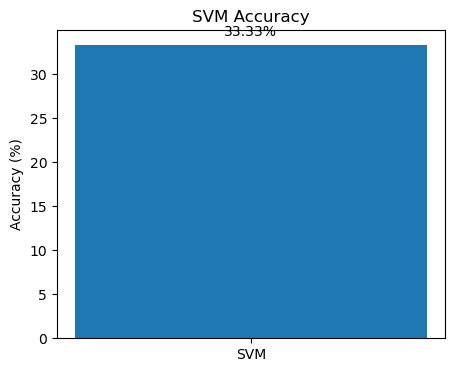

In [72]:
import matplotlib.pyplot as plt

accuracy = 33.33

plt.figure(figsize=(5,4))

plt.bar(['SVM'], [accuracy])

plt.title('SVM Accuracy')
plt.ylabel('Accuracy (%)')

plt.text(
    0,
    accuracy + 1,
    f'{accuracy:.2f}%',
    ha='center'
)

plt.show()

In [73]:
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

print(cm_svm)

[[2294 4361 3366]
 [2306 4385 3333]
 [2276 4358 3321]]


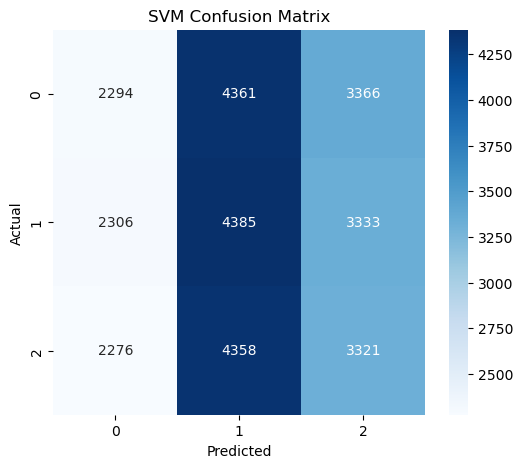

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

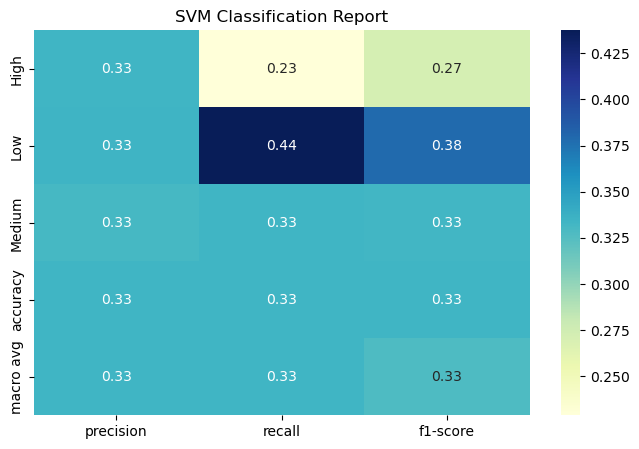

In [75]:
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

report = classification_report(
    y_test,
    y_pred_svm,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,5))

sns.heatmap(
    report_df.iloc[:-1,:-1],
    annot=True,
    cmap='YlGnBu'
)

plt.title(
    'SVM Classification Report'
)

plt.show()

In [76]:
print(cm_svm)

print(classification_report(y_test, y_pred_svm))

[[2294 4361 3366]
 [2306 4385 3333]
 [2276 4358 3321]]
              precision    recall  f1-score   support

        High       0.33      0.23      0.27     10021
         Low       0.33      0.44      0.38     10024
      Medium       0.33      0.33      0.33      9955

    accuracy                           0.33     30000
   macro avg       0.33      0.33      0.33     30000
weighted avg       0.33      0.33      0.33     30000



In [77]:
!pip install xgboost

In [78]:
print(y_train.unique())

['Low' 'High' 'Medium']


In [79]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(df['burnout_level'])

print(le.classes_)

['High' 'Low' 'Medium']


In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(set(y_train))

{np.int64(0), np.int64(1), np.int64(2)}


In [81]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

acc_xgb = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy =", acc_xgb)

XGBoost Accuracy = 0.3355666666666667


In [82]:
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print(cm_xgb)

[[3153 3726 3142]
 [3128 3741 3155]
 [3083 3699 3173]]


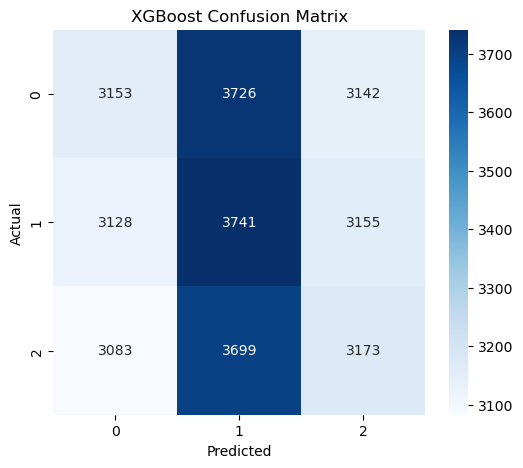

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [84]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.34      0.31      0.33     10021
           1       0.34      0.37      0.35     10024
           2       0.34      0.32      0.33      9955

    accuracy                           0.34     30000
   macro avg       0.34      0.34      0.34     30000
weighted avg       0.34      0.34      0.34     30000



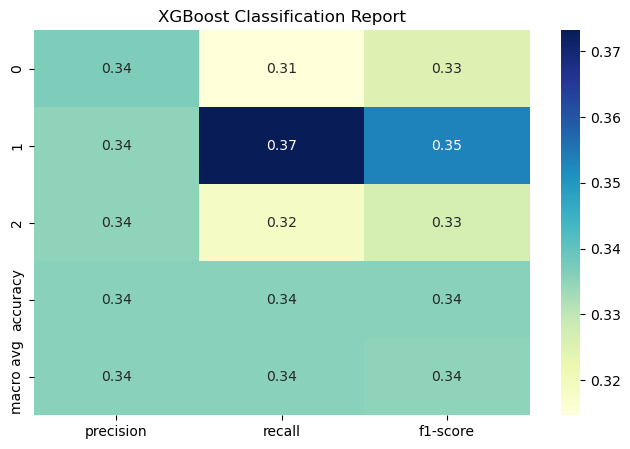

In [85]:
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

report = classification_report(
    y_test,
    y_pred_xgb,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,5))

sns.heatmap(
    report_df.iloc[:-1,:-1],
    annot=True,
    cmap='YlGnBu'
)

plt.title('XGBoost Classification Report')

plt.show()

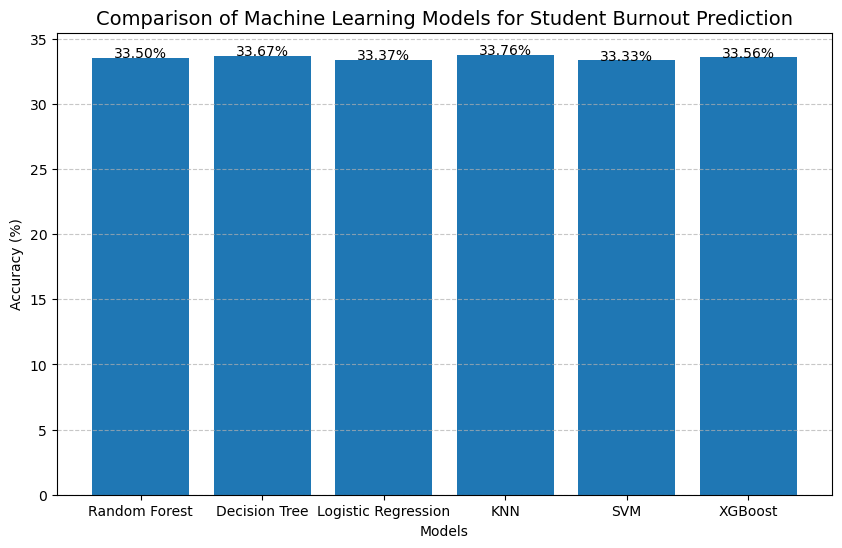

In [86]:
import matplotlib.pyplot as plt

models = [
    'Random Forest',
    'Decision Tree',
    'Logistic Regression',
    'KNN',
    'SVM',
    'XGBoost'
]

accuracy = [
    33.50,
    33.67,
    33.37,
    33.76,
    33.33,
    33.56
]

plt.figure(figsize=(10,6))

bars = plt.bar(models, accuracy)

plt.title(
    'Comparison of Machine Learning Models for Student Burnout Prediction',
    fontsize=14
)

plt.xlabel('Models')
plt.ylabel('Accuracy (%)')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f'{bar.get_height():.2f}%',
        ha='center'
    )

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [87]:
import pandas as pd

accuracy_table = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Decision Tree",
        "Logistic Regression",
        "KNN",
        "SVM",
        "XGBoost"
    ],
    "Accuracy (%)": [
        33.50,
        33.67,
        33.37,
        33.76,
        33.33,
        33.56
    ]
})

accuracy_table.sort_values("Accuracy (%)", ascending=False)

,Model,Accuracy (%)
3,KNN,33.76
1,Decision Tree,33.67
5,XGBoost,33.56
0,Random Forest,33.50
2,Logistic Regression,33.37
4,SVM,33.33


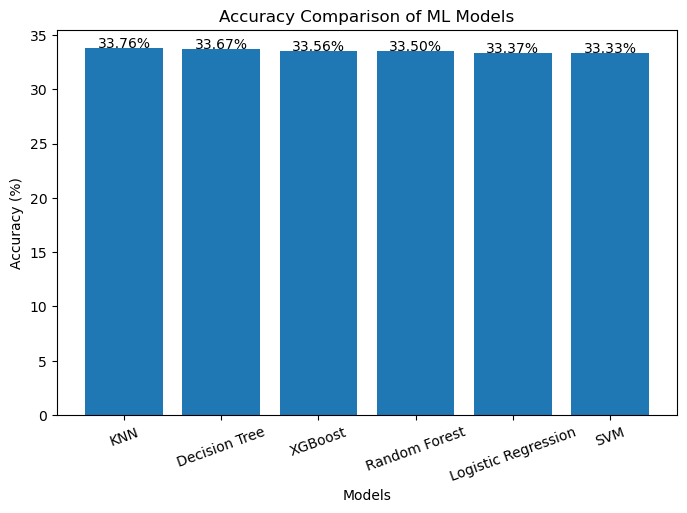

In [88]:
import matplotlib.pyplot as plt

accuracy_table = accuracy_table.sort_values(
    by="Accuracy (%)",
    ascending=False
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    accuracy_table["Model"],
    accuracy_table["Accuracy (%)"]
)

plt.title("Accuracy Comparison of ML Models")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=20)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        y+0.03,
        f"{y:.2f}%",
        ha='center'
    )

plt.show()

In [93]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
11,cgpa,0.083821
10,attendance_percentage,0.083217
12,Rest_to_Work_Ratio,0.082818
1,daily_study_hours,0.075272
3,screen_time_hours,0.075123
2,daily_sleep_hours,0.069763
9,physical_activity_hours,0.060644
7,financial_stress_score,0.049055
4,anxiety_score,0.048659
8,social_support_score,0.048188


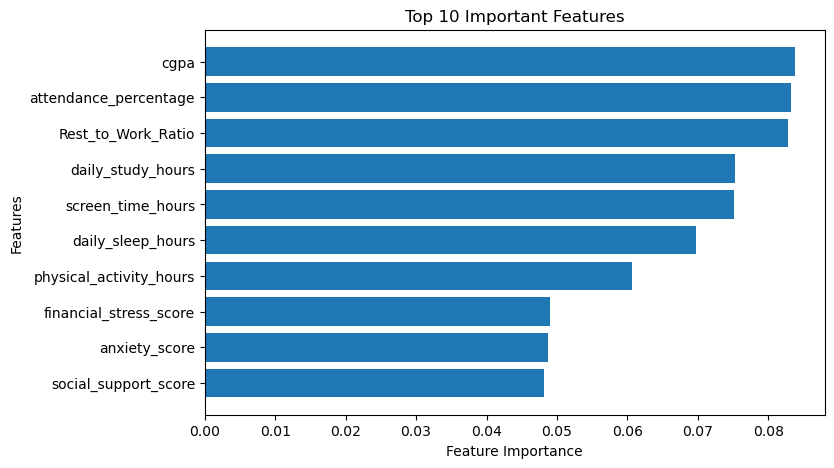

In [94]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(top10["Feature"], top10["Importance"])

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.show()

In [95]:
rwr_summary = df['Rest_to_Work_Ratio'].describe()

print(rwr_summary)

count    150000.000000
mean          0.731422
std           0.401629
min           0.186047
25%           0.477419
50%           0.624161
75%           0.851852
max           4.909091
Name: Rest_to_Work_Ratio, dtype: float64


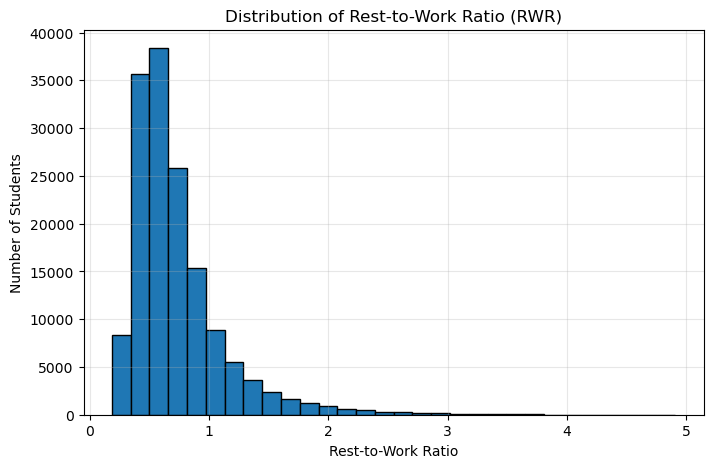

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df['Rest_to_Work_Ratio'],
    bins=30,
    edgecolor='black'
)

plt.title("Distribution of Rest-to-Work Ratio (RWR)")
plt.xlabel("Rest-to-Work Ratio")
plt.ylabel("Number of Students")

plt.grid(alpha=0.3)

plt.show()

In [97]:
import pandas as pd

rwr_table = pd.DataFrame({
    "Statistic": ["Minimum", "25%", "Median", "Mean", "75%", "Maximum"],
    "Value": [
        df['Rest_to_Work_Ratio'].min(),
        df['Rest_to_Work_Ratio'].quantile(0.25),
        df['Rest_to_Work_Ratio'].median(),
        df['Rest_to_Work_Ratio'].mean(),
        df['Rest_to_Work_Ratio'].quantile(0.75),
        df['Rest_to_Work_Ratio'].max()
    ]
})

rwr_table

,Statistic,Value
0,Minimum,0.186047
1,25%,0.477419
2,Median,0.624161
3,Mean,0.731422
4,75%,0.851852
5,Maximum,4.909091


In [98]:
burnout_table = df['burnout_level'].value_counts().reset_index()

burnout_table.columns = ['Burnout Level', 'Number of Students']

burnout_table

,Burnout Level,Number of Students
0,Low,50265
1,Medium,49969
2,High,49766


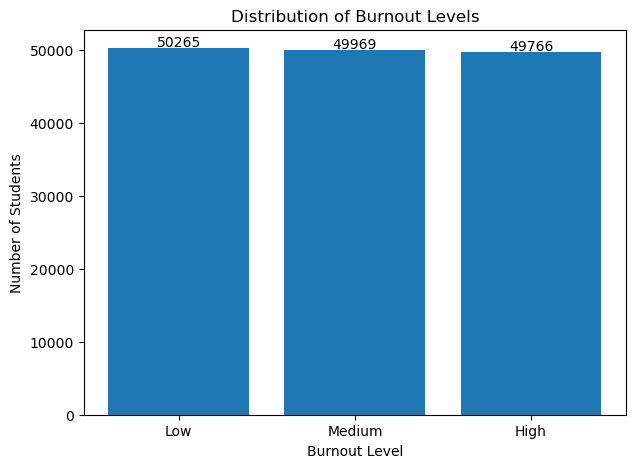

In [99]:
import matplotlib.pyplot as plt

burnout_counts = df['burnout_level'].value_counts()

plt.figure(figsize=(7,5))

bars = plt.bar(
    burnout_counts.index,
    burnout_counts.values
)

plt.title("Distribution of Burnout Levels")
plt.xlabel("Burnout Level")
plt.ylabel("Number of Students")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 200,
        str(int(y)),
        ha='center'
    )

plt.show()

In [100]:
burnout_percentage = (
    df['burnout_level']
    .value_counts(normalize=True)
    * 100
).round(2)

burnout_percentage

burnout_level
Low       33.51
Medium    33.31
High      33.18
Name: proportion, dtype: float64

In [101]:
missing_values = df.isnull().sum().reset_index()

missing_values.columns = ["Feature", "Missing Values"]

missing_values

,Feature,Missing Values
0,age,0
1,gender,0
2,course,0
3,year,0
4,daily_study_hours,0
5,daily_sleep_hours,0
6,screen_time_hours,0
7,stress_level,0
8,anxiety_score,0
9,depression_score,0


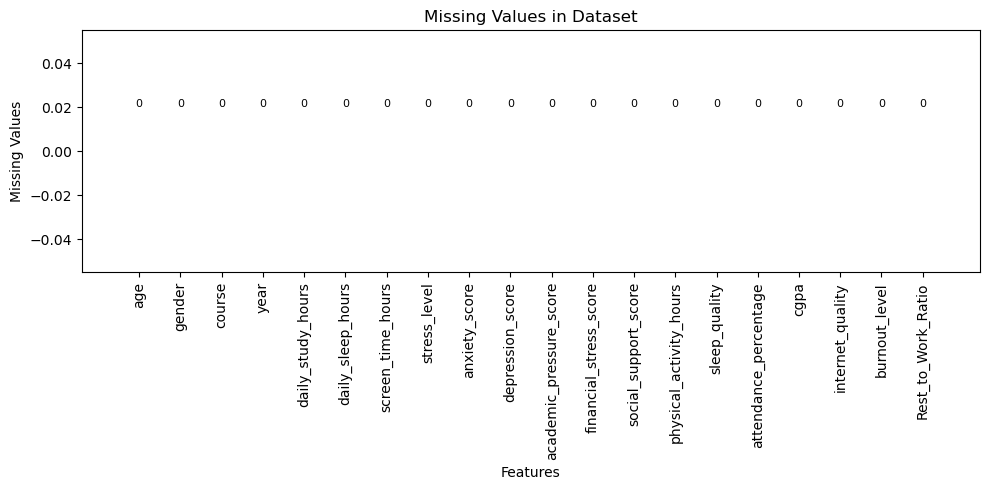

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

bars = plt.bar(
    missing_values["Feature"],
    missing_values["Missing Values"]
)

plt.title("Missing Values in Dataset")
plt.xlabel("Features")
plt.ylabel("Missing Values")

plt.xticks(rotation=90)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.02,
        int(y),
        ha='center',
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [103]:
stress_table = pd.crosstab(
    df['stress_level'],
    df['burnout_level']
)

stress_table

burnout_level,High,Low,Medium
stress_level,,,
High,16768,16868,16659
Low,16357,16711,16547
Medium,16641,16686,16763


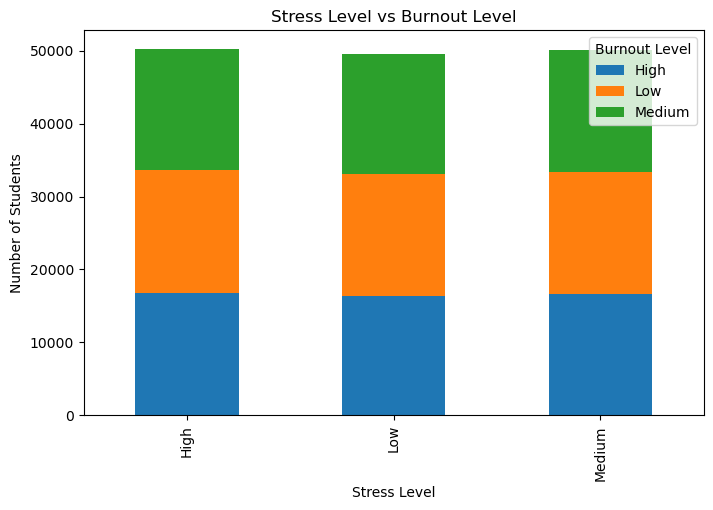

In [104]:
stress_table.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Stress Level vs Burnout Level")
plt.xlabel("Stress Level")
plt.ylabel("Number of Students")

plt.legend(title="Burnout Level")

plt.show()

In [105]:
sleep_table = pd.crosstab(
    df['sleep_quality'],
    df['burnout_level']
)

sleep_table

burnout_level,High,Low,Medium
sleep_quality,,,
Average,16497,16764,16715
Good,16571,16717,16855
Poor,16698,16784,16399


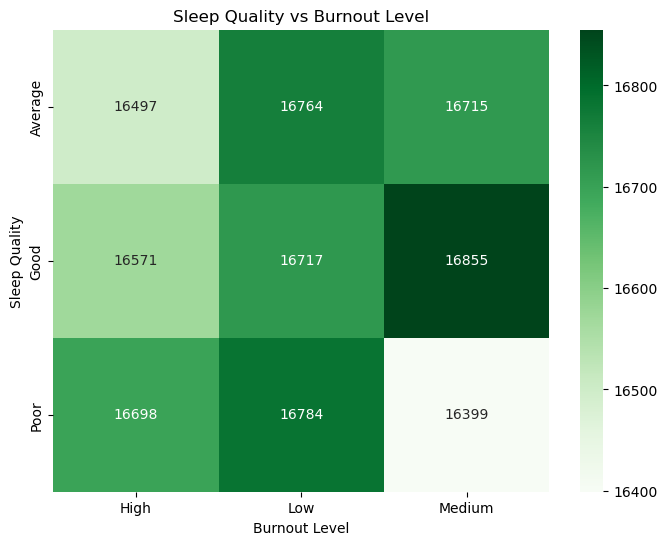

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    sleep_table,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Sleep Quality vs Burnout Level")
plt.xlabel("Burnout Level")
plt.ylabel("Sleep Quality")

plt.show()

In [108]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Decision Tree",
        "Logistic Regression",
        "KNN",
        "SVM",
        "XGBoost"
    ],
    "Accuracy (%)": [
        33.50,
        33.67,
        33.37,
        33.76,
        33.33,
        33.56
    ]
})

comparison = comparison.sort_values(
    by="Accuracy (%)",
    ascending=False
)

comparison


,Model,Accuracy (%)
3,KNN,33.76
1,Decision Tree,33.67
5,XGBoost,33.56
0,Random Forest,33.50
2,Logistic Regression,33.37
4,SVM,33.33


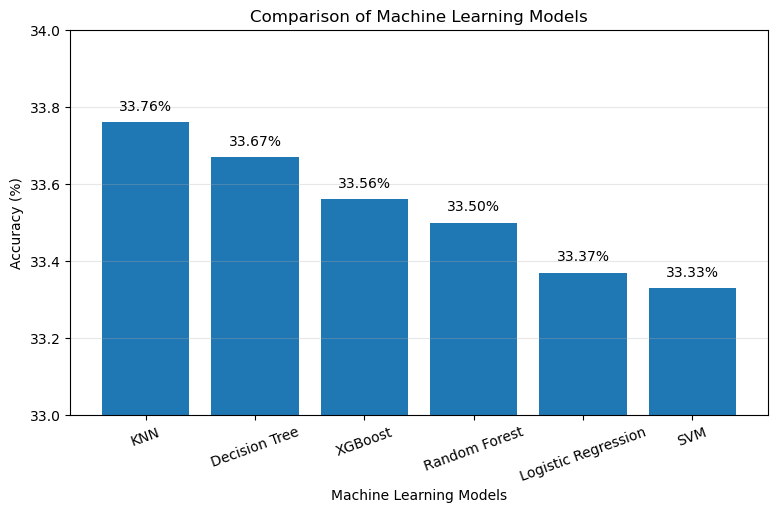

In [109]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

bars = plt.bar(
    comparison["Model"],
    comparison["Accuracy (%)"]
)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=20)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.03,
        f"{y:.2f}%",
        ha='center'
    )

plt.ylim(33, 34)

plt.grid(axis='y', alpha=0.3)

plt.show()

In [110]:
importance.head(10)

,Feature,Importance
11,cgpa,0.083821
10,attendance_percentage,0.083217
12,Rest_to_Work_Ratio,0.082818
1,daily_study_hours,0.075272
3,screen_time_hours,0.075123
2,daily_sleep_hours,0.069763
9,physical_activity_hours,0.060644
7,financial_stress_score,0.049055
4,anxiety_score,0.048659
8,social_support_score,0.048188


In [111]:
selected_features = importance[
    importance["Feature"].isin([
        "cgpa",
        "attendance_percentage",
        "Rest_to_Work_Ratio",
        "daily_study_hours",
        "daily_sleep_hours",
        "screen_time_hours"
    ])
]

selected_features

,Feature,Importance
11,cgpa,0.083821
10,attendance_percentage,0.083217
12,Rest_to_Work_Ratio,0.082818
1,daily_study_hours,0.075272
3,screen_time_hours,0.075123
2,daily_sleep_hours,0.069763


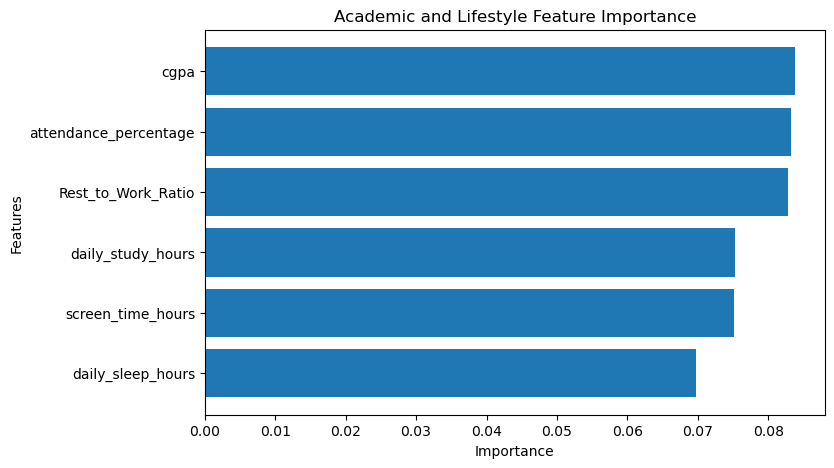

In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(
    selected_features["Feature"],
    selected_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Academic and Lifestyle Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()

In [113]:
comparison["Difference from Best (%)"] = (
    comparison["Accuracy (%)"].max()
    - comparison["Accuracy (%)"]
).round(2)

comparison

,Model,Accuracy (%),Difference from Best (%)
3,KNN,33.76,0.00
1,Decision Tree,33.67,0.09
5,XGBoost,33.56,0.20
0,Random Forest,33.50,0.26
2,Logistic Regression,33.37,0.39
4,SVM,33.33,0.43


In [114]:
import pandas as pd

dataset_quality = pd.DataFrame({
    "Quality Check": [
        "Total Records",
        "Total Features",
        "Missing Values",
        "Duplicate Records"
    ],
    "Result": [
        len(df),
        len(df.columns),
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

dataset_quality

,Quality Check,Result
0,Total Records,150000
1,Total Features,20
2,Missing Values,0
3,Duplicate Records,0


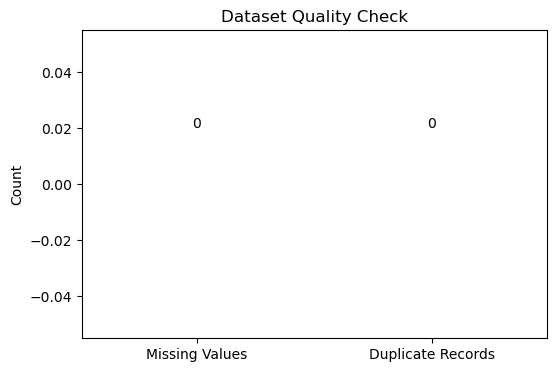

In [115]:
import matplotlib.pyplot as plt

quality_chart = pd.DataFrame({
    "Metric": [
        "Missing Values",
        "Duplicate Records"
    ],
    "Count": [
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

plt.figure(figsize=(6,4))

bars = plt.bar(
    quality_chart["Metric"],
    quality_chart["Count"]
)

plt.title("Dataset Quality Check")
plt.ylabel("Count")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        y+0.02,
        str(int(y)),
        ha='center'
    )

plt.show()